Ноутбук `exp03_compare_main_mode_baseline.ipynb` предназначен для сравния TF-IDF + Logistic Regression baseline и основнрй RuBERT модели на одном и том же test split.

In [1]:
from pathlib import Path
import random
import yaml
import joblib

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from transformers import AutoTokenizer, AutoModelForSequenceClassification


BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BACKEND_DIR = BASE_DIR.parent
elif BASE_DIR.name == "backend":
    BACKEND_DIR = BASE_DIR
else:
    BACKEND_DIR = BASE_DIR / "backend"


def load_yaml(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as file:
        return yaml.safe_load(file)


directories_config = load_yaml(BACKEND_DIR / "configs" / "directories.yaml")
main_model_config = load_yaml(BACKEND_DIR / "configs" / "main_model_config.yaml")
exp01_config = load_yaml(BACKEND_DIR / "configs" / "exp01_config.yaml")


def configured_path(name: str) -> Path:
    return (BACKEND_DIR / directories_config["paths"][name]).resolve()


DATASET_PATH = configured_path("dataset")
BASELINE_MODEL_PATH = configured_path("exp01_baseline_model")
MAIN_MODEL_DIR = configured_path("final_model_dir")
EXP03_DIR = configured_path("exp03_dir")
EXP03_FIGURES_DIR = configured_path("exp03_figures_dir")
EXP03_TABLES_DIR = configured_path("exp03_tables_dir")
METRICS_CSV_PATH = configured_path("exp03_metrics_csv")
CONFUSION_MATRICES_PATH = configured_path("exp03_confusion_matrices")

EXP03_DIR.mkdir(parents=True, exist_ok=True)
EXP03_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXP03_TABLES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = main_model_config["random_state"]
MAX_LENGTH = main_model_config["model"]["max_length"]

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
df = pd.read_csv(DATASET_PATH, sep=";")

print(df.shape)
print(df["label"].value_counts())
df.head()

(1000, 3)
label
PAYMENT_OUT_FAIL    131
INCOMING_DELAY      131
APP_LOGIN           131
CARD_ISSUE          129
ACCOUNT_SEIZED      129
FRAUD_SUSPECTED     124
KYC_VERIFICATION    124
APP_TECH            101
Name: count, dtype: int64


,ID,text,label
0,1,"Регулярный платёж списался частично, остаток в...",PAYMENT_OUT_FAIL
1,2,задержка по кэшбэку уже 9 рабочих дней когда н...,INCOMING_DELAY
2,3,Face ID крутится и возвращает на экран логина....,APP_LOGIN
3,4,аналитика расходов крутится бесконечно данных ...,APP_TECH
4,5,звонили представились банком просили код ничег...,FRAUD_SUSPECTED


In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=main_model_config["split"]["test_size"],
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=main_model_config["split"]["validation_size"],
    random_state=RANDOM_STATE,
    stratify=train_df["label"],
)

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)
print(test_df["label"].value_counts())

labels = sorted(df["label"].unique())

train: (562, 3)
validation: (188, 3)
test: (250, 3)
label
APP_LOGIN           33
INCOMING_DELAY      33
PAYMENT_OUT_FAIL    33
CARD_ISSUE          32
ACCOUNT_SEIZED      32
FRAUD_SUSPECTED     31
KYC_VERIFICATION    31
APP_TECH            25
Name: count, dtype: int64


In [4]:
if BASELINE_MODEL_PATH.exists():
    baseline_model = joblib.load(BASELINE_MODEL_PATH)
else:
    tfidf_config = exp01_config["tfidf"]
    logreg_config = exp01_config["logistic_regression"]

    baseline_model = Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer=tfidf_config.get("analyzer", "word"),
            ngram_range=tuple(tfidf_config.get("ngram_range", [1, 2])),
            max_features=tfidf_config.get("max_features", tfidf_config.get("max_feauters")),
        )),
        ("classifier", LogisticRegression(
            max_iter=logreg_config.get("max_iter", 1000),
            class_weight=logreg_config.get("class_weight", "balanced"),
            random_state=logreg_config.get("random_state", RANDOM_STATE),
        )),
    ])

    baseline_model.fit(train_df["text"], train_df["label"])
    BASELINE_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(baseline_model, BASELINE_MODEL_PATH)

baseline_preds = baseline_model.predict(test_df["text"])

/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/sklearn/b

In [5]:
if not MAIN_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Директория основной модели не найдена: {MAIN_MODEL_DIR}. "
    )

tokenizer = AutoTokenizer.from_pretrained(MAIN_MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MAIN_MODEL_DIR)
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [6]:
def predict_main_model(texts: list[str], batch_size: int = 16) -> list[str]:
    predictions = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}

        with torch.inference_mode():
            logits = model(**encoded).logits
            pred_ids = torch.argmax(logits, dim=-1).cpu().tolist()

        predictions.extend(model.config.id2label[int(pred_id)] for pred_id in pred_ids)

    return predictions


main_model_preds = predict_main_model(test_df["text"].tolist())

In [7]:
def calculate_metrics(y_true, y_pred) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }


comparison_df = pd.DataFrame([
    {"model": "TF-IDF + Logistic Regression", **calculate_metrics(test_df["label"], baseline_preds)},
    {"model": "BERT/RuBERT fine-tuned", **calculate_metrics(test_df["label"], main_model_preds)},
])

comparison_df.to_csv(METRICS_CSV_PATH, index=False)
comparison_df

,model,accuracy,f1_macro,f1_weighted
0,TF-IDF + Logistic Regression,0.932,0.933120,0.932204
1,BERT/RuBERT fine-tuned,0.928,0.925953,0.927225


In [8]:
print("Baseline classification report")
print(classification_report(test_df["label"], baseline_preds, labels=labels))

print("\nMain model classification report")
print(classification_report(test_df["label"], main_model_preds, labels=labels))

Baseline classification report
                  precision    recall  f1-score   support

  ACCOUNT_SEIZED       1.00      0.88      0.93        32
       APP_LOGIN       0.89      0.94      0.91        33
        APP_TECH       1.00      0.92      0.96        25
      CARD_ISSUE       0.91      1.00      0.96        32
 FRAUD_SUSPECTED       0.93      0.87      0.90        31
  INCOMING_DELAY       1.00      0.97      0.98        33
KYC_VERIFICATION       0.94      1.00      0.97        31
PAYMENT_OUT_FAIL       0.83      0.88      0.85        33

        accuracy                           0.93       250
       macro avg       0.94      0.93      0.93       250
    weighted avg       0.94      0.93      0.93       250


Main model classification report
                  precision    recall  f1-score   support

  ACCOUNT_SEIZED       0.89      1.00      0.94        32
       APP_LOGIN       0.84      0.97      0.90        33
        APP_TECH       1.00      0.80      0.89        25
   

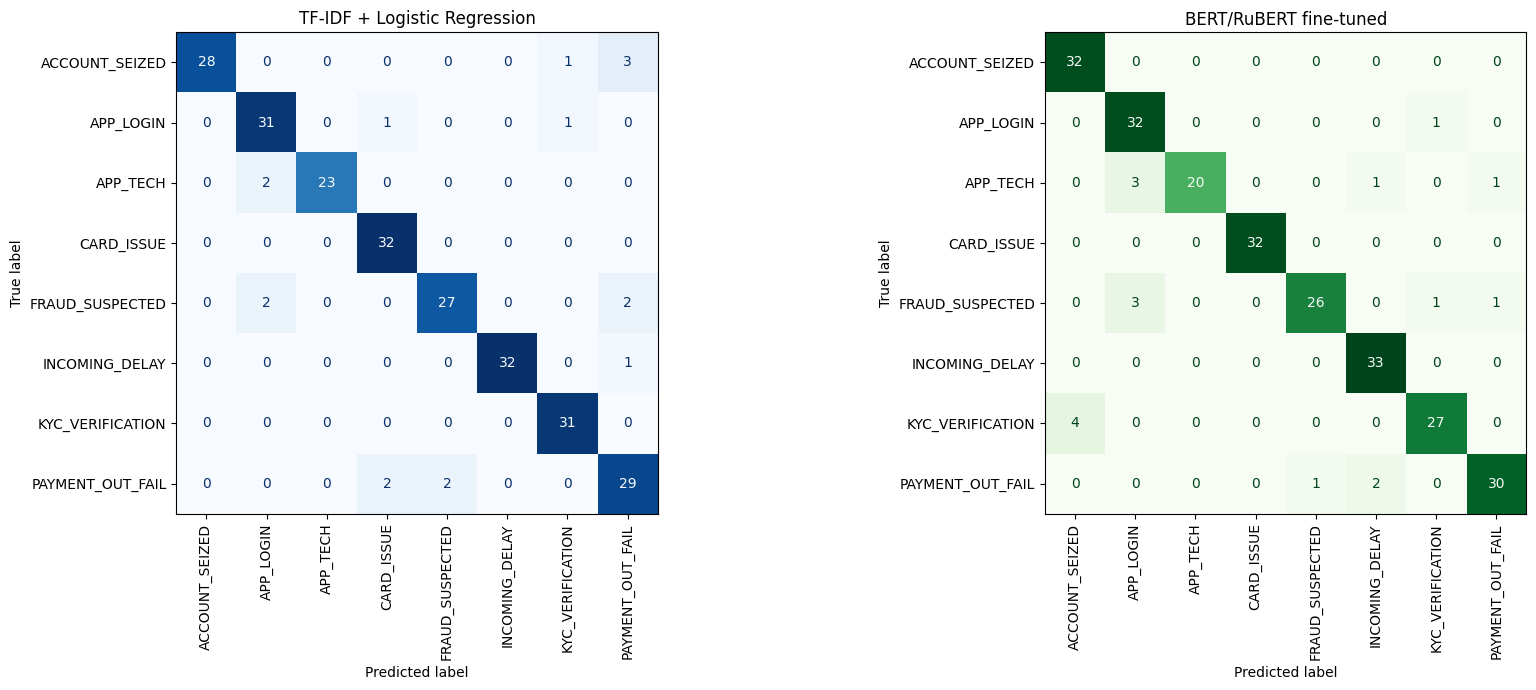

In [9]:
baseline_conf_matr = confusion_matrix(test_df["label"], baseline_preds, labels=labels)
main_model_conf_matr = confusion_matrix(test_df["label"], main_model_preds, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay(baseline_conf_matr, display_labels=labels).plot(
    ax=axes[0], xticks_rotation=90, cmap="Blues", values_format="d", colorbar=False
)
axes[0].set_title("TF-IDF + Logistic Regression")

ConfusionMatrixDisplay(main_model_conf_matr, display_labels=labels).plot(
    ax=axes[1], xticks_rotation=90, cmap="Greens", values_format="d", colorbar=False
)
axes[1].set_title("BERT/RuBERT fine-tuned")

plt.tight_layout()
plt.savefig(CONFUSION_MATRICES_PATH, dpi=300, bbox_inches="tight")
plt.show()

In [10]:
errors_df = test_df.copy()
errors_df["baseline_pred"] = baseline_preds
errors_df["main_model_pred"] = main_model_preds
errors_df = errors_df[errors_df["label"] != errors_df["main_model_pred"]]

errors_df[["text", "label", "baseline_pred", "main_model_pred"]].head(20)

,text,label,baseline_pred,main_model_pred
574,история операций пустая хотя вчера были движения,APP_TECH,APP_TECH,INCOMING_DELAY
33,письмо подтверждения почты приходит без рабоче...,APP_LOGIN,APP_LOGIN,KYC_VERIFICATION
432,письмо «подтвердите аккаунт» похоже на фишинг ...,FRAUD_SUSPECTED,APP_LOGIN,KYC_VERIFICATION
743,"Получил письмо «подтвердите аккаунт», перешёл ...",FRAUD_SUSPECTED,FRAUD_SUSPECTED,APP_LOGIN
455,платеж ушел в неизвестный статус в истории пусто,PAYMENT_OUT_FAIL,PAYMENT_OUT_FAIL,FRAUD_SUSPECTED
740,перешёл на фальшивый сайт похожий на ваш ввёл ...,FRAUD_SUSPECTED,APP_LOGIN,APP_LOGIN
405,источник средств требуются справки куда грузить,KYC_VERIFICATION,KYC_VERIFICATION,ACCOUNT_SEIZED
857,загрузил коммунальный счет как подтверждение а...,KYC_VERIFICATION,KYC_VERIFICATION,ACCOUNT_SEIZED
156,веб показывает авторизацию с нового устройства...,FRAUD_SUSPECTED,FRAUD_SUSPECTED,APP_LOGIN
319,кнопка «Отправить» в чате поддержки не активна,APP_TECH,APP_TECH,APP_LOGIN
